# Finetuning + SLERP + Continuous CoOp Prompt Search

This notebook is a clean experiment notebook for compositional CelebA retrieval. It combines three ideas:

1. **SLERP over attributes**: each signed query is composed on the CLIP unit sphere instead of by plain vector addition.
2. **SLERP over text and image**: the final retrieval vector is a spherical interpolation between the learned text direction and the reference image vector.
3. **Neural prompt/adaptation search**: inspired by `road_to_finetuning.ipynb` and the NOAH idea, the trainable model searches over prompt length, adapters, LoRA-style low-rank residuals, negative weighting, and image/text fusion.

The key difference from the earlier lightweight CoOp cell is important: this notebook learns **continuous prompt tokens**. It does not learn literal words, and it does not learn weights over hand-written prompt templates. CLIP stays frozen; the trainable parameters are small prompt-token tensors plus optional parameter-efficient residual modules.

## Process Overview

For one case, the retrieval problem is:

```text
reference image + signed attribute query -> target image ranking
```

Example:

```text
+Smiling, -Eyeglasses
```

The model handles that query as follows:

1. Parse the signed attributes.
2. For each positive attribute, encode a learned positive CoOp prompt.
3. For each negative attribute, encode a learned negative CoOp prompt.
4. Compose those attribute vectors with SLERP on the CLIP sphere.
5. Fuse the composed text vector with the reference image vector using SLERP again.
6. Optionally pass reference/text/fused vectors through searched adapters or LoRA-style low-rank residuals.
7. Train with a sampled retrieval cross-entropy loss: the edited vector should rank a ground-truth target above sampled negatives.

The searched architecture is not a full reproduction of transformer-block NOAH. It is the same *principle* adapted to this retrieval setting: a supernet contains multiple small adaptation choices, and validation retrieval chooses which structure works best.

In [1]:
import json
import random
import zipfile
from dataclasses import dataclass
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
from torchvision.datasets import CelebA
import transformers
from transformers import CLIPModel, CLIPProcessor

%matplotlib inline

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"torch={torch.__version__}, transformers={transformers.__version__}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

Using device: cuda
torch=2.12.1+cu126, transformers=5.12.1
CUDA device: Tesla T4


## Data Paths

The path logic mirrors `slerp/multiple_slerps.ipynb`: Colab uses Drive archives if available; VM/local mode expects the shared `/home/disi/deep_learning/DeepLearning2026/data` layout. Edit the constants in this cell if your data is somewhere else.

In [2]:
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)

if IN_COLAB:
    DATA_ROOT = Path("/content/datasets")
    DRIVE_DATA_ROOT = Path("/content/drive/MyDrive/deep_learning/data")
    CELEBA_ZIP = DRIVE_DATA_ROOT / "celeba.zip"
    FROZEN_DATA_ZIP = DRIVE_DATA_ROOT / "frozen_data.zip"
    ANNOTATIONS_PATH = DRIVE_DATA_ROOT / "celeba_evaluation.json"
    CELEBA_ROOT = DATA_ROOT
    FROZEN_DATA_ROOT = DATA_ROOT / "frozen_data"
else:
    DATA_ROOT = Path("/home/disi/deep_learning/DeepLearning2026/data")
    CELEBA_ZIP = DATA_ROOT / "celeba.zip"
    FROZEN_DATA_ZIP = DATA_ROOT / "frozen_data.zip"
    ANNOTATIONS_PATH = DATA_ROOT / "celeba_evaluation.json"
    CELEBA_ROOT = DATA_ROOT / "celeba"
    FROZEN_DATA_ROOT = DATA_ROOT / "frozen_data"

if IN_COLAB:
    DATA_ROOT.mkdir(parents=True, exist_ok=True)
    FROZEN_DATA_ROOT.mkdir(parents=True, exist_ok=True)


def describe_path(label: str, path: Path) -> None:
    print(f"{label}: {path} | exists={path.exists()} | is_dir={path.is_dir()}")

print("Path mode:", "Colab/Drive" if IN_COLAB else "VM/local")
describe_path("DATA_ROOT", DATA_ROOT)
describe_path("CELEBA_ROOT", CELEBA_ROOT)
print(f"ANNOTATIONS_PATH: {ANNOTATIONS_PATH} | exists={ANNOTATIONS_PATH.exists()} | is_file={ANNOTATIONS_PATH.is_file()}")
describe_path("FROZEN_DATA_ROOT", FROZEN_DATA_ROOT)

Path mode: VM/local
DATA_ROOT: /home/disi/deep_learning/DeepLearning2026/data | exists=True | is_dir=True
CELEBA_ROOT: /home/disi/deep_learning/DeepLearning2026/data/celeba | exists=True | is_dir=True
ANNOTATIONS_PATH: /home/disi/deep_learning/DeepLearning2026/data/celeba_evaluation.json | exists=True | is_file=True
FROZEN_DATA_ROOT: /home/disi/deep_learning/DeepLearning2026/data/frozen_data | exists=True | is_dir=True


In [3]:
def unzip_if_needed(zip_path: Path, target_dir: Path, marker_glob: str, description: str) -> None:
    target_dir.mkdir(parents=True, exist_ok=True)
    already_present = any(target_dir.rglob(marker_glob))
    if already_present:
        print(f"{description}: already present in {target_dir}")
        return
    if not zip_path.exists():
        print(f"{description}: zip not found at {zip_path}. Skipping extraction.")
        return
    print(f"{description}: extracting {zip_path.name} -> {target_dir}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(target_dir)

if IN_COLAB:
    unzip_if_needed(CELEBA_ZIP, CELEBA_ROOT, "*.jpg", "CelebA images")
    unzip_if_needed(FROZEN_DATA_ZIP, FROZEN_DATA_ROOT, "*.pt", "Frozen CLIP visual features")
else:
    print("VM/local mode: using pre-extracted data; no zip extraction will be attempted.")

VM/local mode: using pre-extracted data; no zip extraction will be attempted.


In [4]:
def find_pt_directory(root: Path) -> Path:
    if any(root.glob("*.pt")):
        return root
    candidates = [p.parent for p in root.rglob("*.pt")]
    if not candidates:
        raise FileNotFoundError(
            f"No .pt visual feature files found under {root}. "
            "Check FROZEN_DATA_ROOT or extract frozen_data.zip."
        )
    return max(set(candidates), key=lambda p: sum(1 for _ in p.glob("*.pt")))

VISUAL_FEATURE_DIR = find_pt_directory(FROZEN_DATA_ROOT)
print("Using visual features from:", VISUAL_FEATURE_DIR)
print("Number of .pt files:", sum(1 for _ in VISUAL_FEATURE_DIR.glob("*.pt")))

if not ANNOTATIONS_PATH.exists():
    raise FileNotFoundError(f"Missing annotations file: {ANNOTATIONS_PATH}")

with open(ANNOTATIONS_PATH, "r") as f:
    annotations = json.load(f)

print(f"Loaded {len(annotations)} evaluation queries")
queries_df = pd.DataFrame({"query_id": range(len(annotations)), "query": [a["query"] for a in annotations]})
queries_df

Using visual features from: /home/disi/deep_learning/DeepLearning2026/data/frozen_data
Number of .pt files: 19962
Loaded 14 evaluation queries


,query_id,query
0,0,+Smiling
1,1,+Eyeglasses
2,2,-Heavy_Makeup
3,3,+Male
4,4,-Young
5,5,+Blond_Hair
6,6,+Mustache
7,7,-Young
8,8,"+Eyeglasses, +Smiling"
9,9,"+Black_Hair, -Wavy_Hair"


## Frozen CLIP

All CLIP weights are frozen. CoOp learns external continuous prompt-token embeddings; adapter and LoRA modules are separate parameter-efficient layers in projection space.

In [5]:
MODEL_NAME = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(MODEL_NAME).to(device).eval()
processor = CLIPProcessor.from_pretrained(MODEL_NAME)
tokenizer = processor.tokenizer if hasattr(processor, "tokenizer") else processor

for p in model.parameters():
    p.requires_grad_(False)

TEXT_WIDTH = model.config.text_config.hidden_size
PROJECTION_DIM = model.config.projection_dim
MAX_TEXT_LEN = model.config.text_config.max_position_embeddings
EOT_TOKEN_ID = model.config.text_config.eos_token_id

print("Loaded", MODEL_NAME)
print("text hidden width:", TEXT_WIDTH)
print("projection dim:", PROJECTION_DIM)
print("max text length:", MAX_TEXT_LEN)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loaded openai/clip-vit-base-patch32
text hidden width: 512
projection dim: 512
max text length: 77


## Tensor Utilities and Image Bank

The `.pt` files are frozen CLIP image features. They become the retrieval index. The helper keeps image IDs separate from tensor rows so evaluation can use the IDs from `celeba_evaluation.json`.

In [6]:
def safe_torch_load(path: Path, map_location="cpu"):
    try:
        return torch.load(path, map_location=map_location, weights_only=True)
    except TypeError:
        return torch.load(path, map_location=map_location)


def normalize(x: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    return x / x.norm(dim=-1, keepdim=True).clamp_min(eps)


class ImageEmbeddings:
    def __init__(self, ids: list[int], features: torch.Tensor):
        self.ids = [int(i) for i in ids]
        self.embeddings = normalize(features.to(device))
        self.id_to_row = {int(idx): row for row, idx in enumerate(self.ids)}

    @classmethod
    def from_directory(cls, directory: Path, max_images: Optional[int] = None):
        pt_files = sorted(directory.glob("*.pt"), key=lambda p: int(p.stem))
        if max_images is not None:
            pt_files = pt_files[:max_images]
        if not pt_files:
            raise FileNotFoundError(f"No .pt files found in {directory}")
        ids, feats = [], []
        for pt_file in tqdm(pt_files, desc="Loading frozen visual features"):
            tensor = safe_torch_load(pt_file, map_location="cpu")
            if isinstance(tensor, dict):
                tensor = tensor.get("features", tensor.get("image_features"))
            if tensor is None:
                raise ValueError(f"Could not read tensor from {pt_file}")
            ids.append(int(pt_file.stem))
            feats.append(tensor.float().view(-1))
        return cls(ids, torch.stack(feats, dim=0))

    def get(self, image_id: int | str) -> torch.Tensor:
        row = self.id_to_row[int(image_id)]
        return self.embeddings[row:row + 1]

    def batch_get(self, image_ids: list[int | str]) -> torch.Tensor:
        rows = [self.id_to_row[int(image_id)] for image_id in image_ids]
        return self.embeddings[rows]

    def topk(self, query_vec: torch.Tensor, k: int, exclude: Optional[set[int]] = None) -> dict[int, float]:
        query_vec = normalize(query_vec.to(device))
        scores = (query_vec @ self.embeddings.T).squeeze(0)
        if exclude:
            scores = scores.clone()
            for image_id in exclude:
                row = self.id_to_row.get(int(image_id))
                if row is not None:
                    scores[row] = -float("inf")
        values, rows = torch.topk(scores, k=min(k, scores.numel()))
        return {self.ids[int(row)]: float(val) for row, val in zip(rows.detach().cpu(), values.detach().cpu())}

image_embeddings = ImageEmbeddings.from_directory(VISUAL_FEATURE_DIR)
print(f"Image embeddings: {len(image_embeddings.ids)} images, dim={image_embeddings.embeddings.shape[1]}")

Loading frozen visual features:   0%|          | 0/19962 [00:00<?, ?it/s]

Image embeddings: 19962 images, dim=512


## Signed Queries and Cases

Each annotation query is a comma-separated list of signed attributes. The training/evaluation case expands the JSON into one `(query, reference image, ground truth targets)` item.

In [7]:
@dataclass(frozen=True)
class SignedAttribute:
    sign: str
    raw: str


def parse_query(query: str) -> list[SignedAttribute]:
    attrs = []
    for part in query.split(","):
        part = part.strip()
        if not part:
            continue
        if part[0] not in {"+", "-"}:
            raise ValueError(f"Query component must start with + or -: {part!r}")
        attrs.append(SignedAttribute(part[0], part[1:].strip()))
    return attrs


def get_unsigned_queries(annotations: list[dict]) -> list[str]:
    seen = []
    for item in annotations:
        for attr in parse_query(item["query"]):
            if attr.raw not in seen:
                seen.append(attr.raw)
    return seen


def attr_phrase(raw_attr: str) -> str:
    return raw_attr.replace("_", " ").lower()


def positive_suffix(raw_attr: str) -> str:
    attr = attr_phrase(raw_attr)
    if attr == "smiling":
        return "a face that is smiling."
    if attr == "male":
        return "a male face."
    if attr == "young":
        return "a young face."
    if attr.startswith("wearing "):
        return f"a face {attr}."
    return f"a face with {attr}."


def negative_suffix(raw_attr: str) -> str:
    attr = attr_phrase(raw_attr)
    if attr == "male":
        return "a female face."
    if attr == "young":
        return "an old face."
    if attr == "smiling":
        return "a serious unsmiling face."
    return f"a face without {attr}."

raw_attributes = get_unsigned_queries(annotations)
print(f"Attributes in evaluation queries: {len(raw_attributes)}")
raw_attributes

Attributes in evaluation queries: 12


['Smiling',
 'Eyeglasses',
 'Heavy_Makeup',
 'Male',
 'Young',
 'Blond_Hair',
 'Mustache',
 'Black_Hair',
 'Wavy_Hair',
 'Chubby',
 'Wearing_Hat',
 'Wearing_Lipstick']

In [8]:
@dataclass(frozen=True)
class RetrievalCase:
    query_id: int
    query: str
    reference_id: int
    ground_truth: list[int]


def make_cases(
    annotations: list[dict],
    image_embeddings: ImageEmbeddings,
    query_indices: Optional[list[int]] = None,
    max_references_per_query: Optional[int] = None,
) -> list[RetrievalCase]:
    if query_indices is None:
        query_indices = list(range(len(annotations)))

    cases = []
    for query_id in query_indices:
        item = annotations[int(query_id)]
        ref_ids = list(item["ground_truth"].keys())
        if max_references_per_query is not None:
            ref_ids = ref_ids[:max_references_per_query]
        for ref_id in ref_ids:
            if int(ref_id) not in image_embeddings.id_to_row:
                continue
            gt_ids = [int(x) for x in item["ground_truth"][ref_id] if int(x) in image_embeddings.id_to_row]
            if not gt_ids:
                continue
            cases.append(RetrievalCase(int(query_id), item["query"], int(ref_id), gt_ids))
    return cases


def split_cases(cases: list[RetrievalCase], validation_fraction: float = 0.2, seed: int = SEED):
    cases = list(cases)
    rng = random.Random(seed)
    rng.shuffle(cases)
    split_at = max(1, int(round(len(cases) * (1.0 - validation_fraction))))
    return cases[:split_at], cases[split_at:]

small_cases = make_cases(annotations, image_embeddings, query_indices=[0], max_references_per_query=3)
print(f"Small debug cases: {len(small_cases)}")
small_cases[:2]

Small debug cases: 3


[RetrievalCase(query_id=0, query='+Smiling', reference_id=13, ground_truth=[325, 456, 579, 685, 763, 893, 981, 1363, 1646, 2142, 2747, 2812, 2979, 3318, 3325, 3536, 3637, 3932, 4361, 4452, 4549, 4569, 4678, 4780, 4831, 5112, 5208, 5448, 5533, 5926, 6127, 6153, 7595, 7798, 8151, 8342, 8440, 8592, 9009, 9452, 9506, 9612, 9685, 9881, 9930, 9968, 10367, 10719, 10915, 10968, 10973, 11813, 12361, 12673, 12695, 12788, 12934, 12986, 13060, 13141, 13731, 14215, 14323, 14848, 15058, 15422, 15953, 17205, 17384, 17638, 17748, 18096, 18202, 18221, 18290, 18446, 18503, 18799, 19046, 19179, 19800]),
 RetrievalCase(query_id=0, query='+Smiling', reference_id=14, ground_truth=[235, 1787, 2806, 16035, 19731])]

## SLERP in Both Places

There are two spherical operations:

1. `spherical_weighted_average`: combines learned attribute vectors for the signed query.
2. `fuse_text_image_slerp`: combines the composed text vector with the reference image vector.

`image_alpha=0.8` means the final vector stays closer to the reference image. `image_alpha=0.5` means balanced text/image fusion.

In [9]:
def slerp(v0: torch.Tensor, v1: torch.Tensor, alpha: float, eps: float = 1e-6) -> torch.Tensor:
    if not 0.0 <= float(alpha) <= 1.0:
        raise ValueError(f"alpha must be in [0, 1], got {alpha}")
    squeeze = False
    if v0.ndim == 1:
        v0 = v0.unsqueeze(0)
        squeeze = True
    if v1.ndim == 1:
        v1 = v1.unsqueeze(0)
    v0 = normalize(v0)
    v1 = normalize(v1)
    dot = (v0 * v1).sum(dim=-1, keepdim=True).clamp(-1.0, 1.0)
    close = dot.abs() > 0.9995
    theta = torch.acos(dot)
    sin_theta = torch.sin(theta).clamp_min(eps)
    spherical = torch.sin((1.0 - alpha) * theta) / sin_theta * v0 + torch.sin(alpha * theta) / sin_theta * v1
    linear = (1.0 - alpha) * v0 + alpha * v1
    out = torch.where(close, linear, spherical)
    out = normalize(out)
    return out.squeeze(0) if squeeze else out


def spherical_weighted_average(vectors: list[torch.Tensor], weights: list[float]) -> torch.Tensor:
    if not vectors:
        raise ValueError("Need at least one vector")
    if len(vectors) == 1:
        return normalize(vectors[0])
    weights_t = torch.tensor(weights, dtype=torch.float32, device=vectors[0].device).clamp_min(1e-8)
    weights_t = weights_t / weights_t.sum()
    current = normalize(vectors[0])
    cumulative = weights_t[0]
    for vec, w in zip(vectors[1:], weights_t[1:]):
        alpha = float(w / (cumulative + w))
        current = slerp(current, vec, alpha=alpha)
        cumulative = cumulative + w
    return normalize(current)


def fuse_text_image_slerp(text_vec: torch.Tensor, image_vec: torch.Tensor, image_alpha: float) -> torch.Tensor:
    return slerp(text_vec, image_vec, alpha=image_alpha)

## Continuous CoOp Prompt Tokens

For every attribute, the model owns two trainable prompt-token matrices:

```text
positive_ctx[attribute] : [max_ctx, CLIP_text_width]
negative_ctx[attribute] : [max_ctx, CLIP_text_width]
```

A positive attribute prompt is:

```text
[SOS] [learned positive token 1] ... [learned positive token n] a face with attribute [EOS]
```

A negative attribute prompt is:

```text
[SOS] [learned negative token 1] ... [learned negative token n] a face without attribute [EOS]
```

Those learned tokens are continuous vectors inserted directly into CLIP's frozen text transformer. They are not decoded into words and they are not selected from the tokenizer vocabulary.

In [10]:
def expand_attention_mask(attention_mask, dtype):
    if attention_mask is None:
        return None
    expanded_mask = attention_mask[:, None, None, :].to(dtype=dtype)
    return (1.0 - expanded_mask) * torch.finfo(dtype).min


def causal_attention_mask(batch_size, sequence_length, dtype, device):
    mask = torch.full((batch_size, sequence_length, sequence_length), torch.finfo(dtype).min, dtype=dtype, device=device)
    mask = torch.triu(mask, diagonal=1)
    return mask[:, None, :, :]


def clip_text_features_from_embeddings(input_embeddings, input_ids, attention_mask=None):
    text_model = model.text_model
    text_device = next(text_model.parameters()).device
    text_dtype = next(text_model.parameters()).dtype

    input_embeddings = input_embeddings.to(device=text_device, dtype=text_dtype)
    input_ids = input_ids.to(text_device)
    attention_mask = None if attention_mask is None else attention_mask.to(text_device)

    batch_size, sequence_length, _ = input_embeddings.shape
    position_ids = torch.arange(sequence_length, device=text_device).unsqueeze(0)
    hidden_states = input_embeddings + text_model.embeddings.position_embedding(position_ids)

    encoder_kwargs = dict(
        inputs_embeds=hidden_states,
        attention_mask=expand_attention_mask(attention_mask, text_dtype),
        return_dict=True,
    )
    try:
        encoder_outputs = text_model.encoder(
            **encoder_kwargs,
            causal_attention_mask=causal_attention_mask(batch_size, sequence_length, text_dtype, text_device),
        )
    except TypeError:
        encoder_outputs = text_model.encoder(**encoder_kwargs)

    last_hidden_state = text_model.final_layer_norm(encoder_outputs.last_hidden_state)
    eos_positions = input_ids.argmax(dim=-1)
    pooled = last_hidden_state[torch.arange(batch_size, device=text_device), eos_positions]
    text_features = model.text_projection(pooled)
    return normalize(text_features.float())


class SignedCoOpPromptLearner(nn.Module):
    """Learns separate continuous prompt tokens for positive and negative attribute prompts."""

    def __init__(self, attribute_names: list[str], max_ctx: int = 12, ctx_init: str = "a photo of a"):
        super().__init__()
        self.attribute_names = list(attribute_names)
        self.attr_to_idx = {raw.lower(): i for i, raw in enumerate(self.attribute_names)}
        self.max_ctx = int(max_ctx)
        self.hidden_size = TEXT_WIDTH

        self.positive_ctx = nn.Parameter(self._init_context(len(attribute_names), max_ctx, ctx_init))
        self.negative_ctx = nn.Parameter(self._init_context(len(attribute_names), max_ctx, ctx_init))

        self._register_prompt_buffers("positive", [positive_suffix(raw) for raw in attribute_names])
        self._register_prompt_buffers("negative", [negative_suffix(raw) for raw in attribute_names])

    def _init_context(self, n_attr: int, max_ctx: int, ctx_init: str) -> torch.Tensor:
        dtype = next(model.text_model.parameters()).dtype
        if ctx_init:
            tokenized = tokenizer(ctx_init, return_tensors="pt", padding=False, truncation=True).to(device)
            with torch.no_grad():
                init = model.text_model.embeddings.token_embedding(tokenized["input_ids"])[0]
            valid = int(tokenized.get("attention_mask", torch.ones_like(tokenized["input_ids"]))[0].sum().item())
            init = init[:valid][1:-1]
        else:
            init = torch.empty(0, self.hidden_size, device=device, dtype=dtype)
        if init.shape[0] >= max_ctx:
            base = init[:max_ctx]
        else:
            pad = torch.empty(max_ctx - init.shape[0], self.hidden_size, device=device, dtype=dtype)
            nn.init.normal_(pad, std=0.02)
            base = torch.cat([init, pad], dim=0)
        return base.unsqueeze(0).repeat(n_attr, 1, 1).clone().detach().float()

    def _register_prompt_buffers(self, name: str, suffix_texts: list[str]) -> None:
        placeholder = " ".join(["X"] * self.max_ctx)
        prompt_texts = [f"{placeholder} {suffix}" for suffix in suffix_texts]
        tokenized = tokenizer(prompt_texts, padding="max_length", max_length=MAX_TEXT_LEN, truncation=True, return_tensors="pt")
        input_ids = tokenized["input_ids"].to(device)
        attention_mask = tokenized["attention_mask"].to(device)
        with torch.no_grad():
            token_embeddings = model.text_model.embeddings.token_embedding(input_ids)

        self.register_buffer(f"{name}_prefix_embeddings", token_embeddings[:, :1, :].float())
        self.register_buffer(f"{name}_suffix_embeddings", token_embeddings[:, 1 + self.max_ctx :, :].float())
        self.register_buffer(f"{name}_prefix_ids", input_ids[:, :1])
        self.register_buffer(f"{name}_suffix_ids", input_ids[:, 1 + self.max_ctx :])
        self.register_buffer(f"{name}_suffix_attention", attention_mask[:, 1 + self.max_ctx :])

    def _features_for_sign(self, sign_name: str, active_ctx: int) -> torch.Tensor:
        active_ctx = int(active_ctx)
        if not 1 <= active_ctx <= self.max_ctx:
            raise ValueError(f"active_ctx must be in [1, {self.max_ctx}], got {active_ctx}")
        ctx = self.positive_ctx if sign_name == "positive" else self.negative_ctx
        prefix_emb = getattr(self, f"{sign_name}_prefix_embeddings")
        suffix_emb = getattr(self, f"{sign_name}_suffix_embeddings")
        prefix_ids = getattr(self, f"{sign_name}_prefix_ids")
        suffix_ids = getattr(self, f"{sign_name}_suffix_ids")
        suffix_attention = getattr(self, f"{sign_name}_suffix_attention")

        batch = len(self.attribute_names)
        active_ctx_emb = ctx[:, :active_ctx, :]
        prompt_embeddings = torch.cat([prefix_emb, active_ctx_emb, suffix_emb], dim=1)
        ctx_ids = torch.zeros(batch, active_ctx, dtype=prefix_ids.dtype, device=prefix_ids.device)
        input_ids = torch.cat([prefix_ids, ctx_ids, suffix_ids], dim=1)
        prefix_attention = torch.ones(batch, 1, dtype=suffix_attention.dtype, device=suffix_attention.device)
        ctx_attention = torch.ones(batch, active_ctx, dtype=suffix_attention.dtype, device=suffix_attention.device)
        attention_mask = torch.cat([prefix_attention, ctx_attention, suffix_attention], dim=1)
        return clip_text_features_from_embeddings(prompt_embeddings, input_ids, attention_mask)

    def all_attribute_features(self, active_ctx: int) -> tuple[torch.Tensor, torch.Tensor]:
        return self._features_for_sign("positive", active_ctx), self._features_for_sign("negative", active_ctx)

    def query_direction_from_features(self, query: str, positive_features: torch.Tensor, negative_features: torch.Tensor, negative_weight: float = 0.5) -> torch.Tensor:
        pieces = parse_query(query)
        has_pos = any(p.sign == "+" for p in pieces)
        has_neg = any(p.sign == "-" for p in pieces)
        vectors, weights = [], []
        for piece in pieces:
            idx = self.attr_to_idx[piece.raw.lower()]
            if piece.sign == "+":
                vectors.append(positive_features[idx:idx + 1])
                weights.append((1.0 - negative_weight) if has_neg else 1.0)
            else:
                vectors.append(negative_features[idx:idx + 1])
                weights.append(negative_weight if has_pos else 1.0)
        return spherical_weighted_average(vectors, weights)

    def batch_query_directions(self, queries: list[str], active_ctx: int, negative_weight: float = 0.5) -> torch.Tensor:
        positive_features, negative_features = self.all_attribute_features(active_ctx)
        return torch.cat([
            self.query_direction_from_features(query, positive_features, negative_features, negative_weight=negative_weight)
            for query in queries
        ], dim=0)

## Searchable Adapters and LoRA-Style Residuals

The supernet has three possible insertion points: reference image vector, composed text vector, and final fused vector.

For each insertion point, a candidate can choose `none`, `adapter`, `lora`, or `both`. The adapter is a bottleneck residual MLP. The LoRA-style path is a low-rank linear residual. Both live in CLIP projection space and keep the frozen CLIP model untouched.

In [11]:
class ResidualAdapter(nn.Module):
    def __init__(self, dim: int, max_bottleneck: int = 128):
        super().__init__()
        self.max_bottleneck = int(max_bottleneck)
        self.down = nn.Linear(dim, max_bottleneck, bias=False)
        self.up = nn.Linear(max_bottleneck, dim, bias=False)
        nn.init.normal_(self.down.weight, std=0.02)
        nn.init.zeros_(self.up.weight)

    def forward(self, x: torch.Tensor, active_dim: int) -> torch.Tensor:
        active_dim = int(active_dim)
        if active_dim <= 0:
            return x
        z = F.gelu(self.down(x)[..., :active_dim])
        delta = F.linear(z, self.up.weight[:, :active_dim])
        return normalize(x + delta)


class LowRankResidual(nn.Module):
    def __init__(self, dim: int, max_rank: int = 32, scale: float = 1.0):
        super().__init__()
        self.max_rank = int(max_rank)
        self.scale = float(scale)
        self.down = nn.Linear(dim, max_rank, bias=False)
        self.up = nn.Linear(max_rank, dim, bias=False)
        nn.init.normal_(self.down.weight, std=0.02)
        nn.init.zeros_(self.up.weight)

    def forward(self, x: torch.Tensor, rank: int) -> torch.Tensor:
        rank = int(rank)
        if rank <= 0:
            return x
        z = self.down(x)[..., :rank]
        delta = F.linear(z, self.up.weight[:, :rank]) * (self.scale / max(rank, 1))
        return normalize(x + delta)


def apply_module_choice(x, module_choice, adapter, lora, adapter_dim, lora_rank):
    if module_choice in {"adapter", "both"}:
        x = adapter(x, adapter_dim)
    if module_choice in {"lora", "both"}:
        x = lora(x, lora_rank)
    return normalize(x)


class PromptSlerpSearchSupernet(nn.Module):
    """CoOp prompt-token learner plus searchable adapter/LoRA residuals."""

    def __init__(self, attribute_names: list[str], max_ctx: int = 12, max_adapter_dim: int = 128, max_lora_rank: int = 32):
        super().__init__()
        self.prompt_learner = SignedCoOpPromptLearner(attribute_names, max_ctx=max_ctx)
        self.ref_adapter = ResidualAdapter(PROJECTION_DIM, max_adapter_dim)
        self.text_adapter = ResidualAdapter(PROJECTION_DIM, max_adapter_dim)
        self.fused_adapter = ResidualAdapter(PROJECTION_DIM, max_adapter_dim)
        self.ref_lora = LowRankResidual(PROJECTION_DIM, max_lora_rank)
        self.text_lora = LowRankResidual(PROJECTION_DIM, max_lora_rank)
        self.fused_lora = LowRankResidual(PROJECTION_DIM, max_lora_rank)
        self.max_ctx = max_ctx
        self.max_adapter_dim = max_adapter_dim
        self.max_lora_rank = max_lora_rank

    def forward(self, reference_features: torch.Tensor, queries: list[str], candidate: dict) -> torch.Tensor:
        text_features = self.prompt_learner.batch_query_directions(
            queries,
            active_ctx=candidate["active_ctx"],
            negative_weight=candidate["negative_weight"],
        )
        reference_features = normalize(reference_features)
        text_features = normalize(text_features)

        reference_features = apply_module_choice(reference_features, candidate["reference_module"], self.ref_adapter, self.ref_lora, candidate["adapter_dim"], candidate["lora_rank"])
        text_features = apply_module_choice(text_features, candidate["text_module"], self.text_adapter, self.text_lora, candidate["adapter_dim"], candidate["lora_rank"])
        fused = fuse_text_image_slerp(text_features, reference_features, image_alpha=candidate["image_alpha"])
        fused = apply_module_choice(fused, candidate["fused_module"], self.fused_adapter, self.fused_lora, candidate["adapter_dim"], candidate["lora_rank"])
        return normalize(fused)

## Candidate Space

This is the NOAH-style search part. A candidate selects the prompt/adaptation structure to activate inside the supernet.

Important dimensions:

- `active_ctx`: how many learned CoOp tokens are used;
- `negative_weight`: how much mass negative attributes receive during text SLERP;
- `image_alpha`: how close final SLERP stays to the reference image;
- `reference_module`, `text_module`, `fused_module`: whether each location uses no module, an adapter, a LoRA-style low-rank residual, or both.

In [12]:
MODULE_CHOICES = ("none", "adapter", "lora", "both")


def sample_search_candidate(
    active_ctx_choices=(2, 4, 8, 12),
    negative_weights=(0.5, 0.65, 0.8),
    image_alphas=(0.35, 0.5, 0.65, 0.8),
    adapter_dims=(0, 8, 16, 32, 64, 128),
    lora_ranks=(0, 4, 8, 16, 32),
    allow_plain=False,
):
    while True:
        candidate = {
            "active_ctx": int(random.choice(active_ctx_choices)),
            "negative_weight": float(random.choice(negative_weights)),
            "image_alpha": float(random.choice(image_alphas)),
            "adapter_dim": int(random.choice(adapter_dims)),
            "lora_rank": int(random.choice(lora_ranks)),
            "reference_module": random.choice(MODULE_CHOICES),
            "text_module": random.choice(MODULE_CHOICES),
            "fused_module": random.choice(MODULE_CHOICES),
        }
        uses_structure = any(candidate[key] != "none" for key in ["reference_module", "text_module", "fused_module"])
        has_capacity = candidate["adapter_dim"] > 0 or candidate["lora_rank"] > 0
        if allow_plain or uses_structure and has_capacity:
            return candidate


def conservative_candidate():
    return {
        "active_ctx": 4,
        "negative_weight": 0.65,
        "image_alpha": 0.65,
        "adapter_dim": 32,
        "lora_rank": 8,
        "reference_module": "none",
        "text_module": "adapter",
        "fused_module": "lora",
    }

pd.DataFrame([sample_search_candidate() for _ in range(5)])

,active_ctx,negative_weight,image_alpha,adapter_dim,lora_rank,reference_module,text_module,fused_module
0,2,0.50,0.65,8,4,adapter,none,none
1,12,0.50,0.35,0,4,adapter,none,adapter
2,12,0.50,0.80,64,8,none,adapter,both
3,8,0.65,0.50,8,8,none,none,both
4,2,0.65,0.65,64,8,none,both,none


## Training Objective

For each case, one ground-truth target image is sampled as the positive. The model builds an edited target vector and scores it against a candidate pool containing the positive and sampled negatives.

The loss is cross-entropy over candidate images. This is a sampled retrieval loss: cheap enough for notebooks, but aligned with the final ranking metric.

In [13]:
def build_training_pairs(cases: list[RetrievalCase], positives_per_case: int = 1, seed: int = SEED):
    rng = random.Random(seed)
    pairs = []
    for case in cases:
        positives = list(case.ground_truth)
        if positives_per_case is None or positives_per_case >= len(positives):
            selected = positives
        else:
            selected = rng.sample(positives, positives_per_case)
        for target_id in selected:
            pairs.append({"query": case.query, "reference_id": int(case.reference_id), "target_id": int(target_id)})
    return pairs


def candidate_pool_with_labels(positive_ids: torch.Tensor, image_embeddings: ImageEmbeddings, candidate_pool_size: int = 512):
    positive_ids = positive_ids.to(device)
    positive_rows = torch.tensor([image_embeddings.id_to_row[int(x)] for x in positive_ids.detach().cpu().tolist()], device=device)
    bank_size = image_embeddings.embeddings.shape[0]
    if candidate_pool_size is None or candidate_pool_size >= bank_size:
        candidate_rows = torch.arange(bank_size, device=device)
    else:
        random_rows = torch.randint(bank_size, (candidate_pool_size,), device=device)
        candidate_rows = torch.cat([positive_rows, random_rows]).unique()
    labels = (candidate_rows.unsqueeze(0) == positive_rows.unsqueeze(1)).float().argmax(dim=1)
    return candidate_rows, labels


def train_prompt_search_supernet(
    supernet: PromptSlerpSearchSupernet,
    train_cases: list[RetrievalCase],
    image_embeddings: ImageEmbeddings,
    epochs: int = 3,
    batch_size: int = 16,
    lr: float = 2e-3,
    candidate_pool_size: int = 512,
    positives_per_case: int = 1,
    fixed_candidate: Optional[dict] = None,
    seed: int = SEED,
):
    if not train_cases:
        raise ValueError("train_cases is empty")
    torch.manual_seed(seed)
    random.seed(seed)

    supernet.train()
    optimizer = torch.optim.AdamW(supernet.parameters(), lr=lr, weight_decay=0.0)
    image_bank = image_embeddings.embeddings.to(device)
    logit_scale = model.logit_scale.exp().detach().to(device) if hasattr(model, "logit_scale") else torch.tensor(1 / 0.07, device=device)
    pairs = build_training_pairs(train_cases, positives_per_case=positives_per_case, seed=seed)
    history = []

    for epoch in range(1, epochs + 1):
        random.shuffle(pairs)
        losses = []
        progress = tqdm(range(0, len(pairs), batch_size), desc=f"Prompt-search epoch {epoch}/{epochs}")
        for start in progress:
            batch = pairs[start:start + batch_size]
            queries = [item["query"] for item in batch]
            reference_ids = [item["reference_id"] for item in batch]
            positive_ids = torch.tensor([item["target_id"] for item in batch], dtype=torch.long, device=device)

            candidate = fixed_candidate or sample_search_candidate()
            reference_features = image_embeddings.batch_get(reference_ids).to(device)
            target_features = supernet(reference_features, queries, candidate)

            candidate_rows, labels = candidate_pool_with_labels(positive_ids, image_embeddings, candidate_pool_size=candidate_pool_size)
            logits = logit_scale * (target_features @ image_bank[candidate_rows].T)
            loss = F.cross_entropy(logits, labels)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            losses.append(float(loss.detach().cpu()))
            progress.set_postfix(loss=np.mean(losses[-10:]))

        history.append({"epoch": epoch, "loss": float(np.mean(losses)) if losses else float("nan")})
    return pd.DataFrame(history)

## Retrieval Evaluation

The metric function is the same hit-based Recall@K / Precision@K used in the other notebooks. Results can be summarized per query and overall.

In [14]:
def evaluate_retrieval(retrieved_indices: list[int], ground_truth_indices: list[int], k: int):
    top_k_retrieved = retrieved_indices[:k]
    hits = set(top_k_retrieved).intersection(set(ground_truth_indices))
    num_hits = len(hits)
    return {f"Recall@{k}": 1 if num_hits > 0 else 0, f"Precision@{k}": num_hits / k}


@torch.no_grad()
def predict_case(supernet: PromptSlerpSearchSupernet, case: RetrievalCase, candidate: dict, k: int, exclude_reference: bool = True):
    was_training = supernet.training
    supernet.eval()
    reference_feature = image_embeddings.get(case.reference_id).to(device)
    target = supernet(reference_feature, [case.query], candidate)
    exclude = {case.reference_id} if exclude_reference else None
    preds = image_embeddings.topk(target, k=k, exclude=exclude)
    if was_training:
        supernet.train()
    return preds


def run_candidate(supernet, cases, candidate, ks=(1, 5, 10), method_name="prompt_slerp_search"):
    rows = []
    for case in tqdm(cases, desc=method_name):
        predictions = predict_case(supernet, case, candidate, k=max(ks))
        retrieved = list(predictions.keys())
        row = {"method": method_name, "query_id": case.query_id, "query": case.query, "reference_id": case.reference_id, "n_gt": len(case.ground_truth)}
        row.update(candidate)
        for k in ks:
            row.update(evaluate_retrieval(retrieved, case.ground_truth, k))
        rows.append(row)
    return pd.DataFrame(rows)


def summarize_results(results_df: pd.DataFrame):
    metric_cols = [c for c in results_df.columns if c.startswith(("Recall@", "Precision@"))]
    query_summary = results_df.groupby(["query_id", "query"], as_index=False)[metric_cols].mean()
    overall = {"query_id": "ALL", "query": "All selected cases"}
    overall.update({c: results_df[c].mean() for c in metric_cols})
    return pd.concat([query_summary, pd.DataFrame([overall])], ignore_index=True)

## Neural Candidate Search

After supernet training, sample candidate structures and evaluate them on validation cases. The best candidate is selected by an actual retrieval metric, not by random score.

In [15]:
def search_candidates(supernet, validation_cases, num_candidates: int = 12, ks=(1, 5, 10), score_metric: str = "Recall@10", seed: int = SEED):
    if not validation_cases:
        raise ValueError("validation_cases is empty")
    rng_state = random.getstate()
    random.seed(seed)
    rows = []
    best_candidate = None
    best_score = -float("inf")

    for candidate_id in tqdm(range(num_candidates), desc="Searching candidates"):
        candidate = sample_search_candidate(allow_plain=True)
        df = run_candidate(supernet, validation_cases, candidate, ks=ks, method_name=f"candidate_{candidate_id}")
        score = float(df[score_metric].mean())
        row = {"candidate_id": candidate_id, "score_metric": score_metric, "score": score, **candidate}
        rows.append(row)
        if score > best_score:
            best_score = score
            best_candidate = candidate

    random.setstate(rng_state)
    return pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True), best_candidate

## Smoke Test: Instantiate the Supernet

This cell does not train yet. It verifies that continuous prompt tokens flow through CLIP's frozen text encoder and that both SLERP stages return a retrieval vector.

In [16]:
supernet = PromptSlerpSearchSupernet(
    attribute_names=raw_attributes,
    max_ctx=12,
    max_adapter_dim=128,
    max_lora_rank=32,
).to(device)

smoke_candidate = conservative_candidate()
smoke_case = small_cases[0]
smoke_predictions = predict_case(supernet, smoke_case, smoke_candidate, k=5)
print("Smoke case:", smoke_case)
print("Candidate:", smoke_candidate)
print("Predictions:", smoke_predictions)

Smoke case: RetrievalCase(query_id=0, query='+Smiling', reference_id=13, ground_truth=[325, 456, 579, 685, 763, 893, 981, 1363, 1646, 2142, 2747, 2812, 2979, 3318, 3325, 3536, 3637, 3932, 4361, 4452, 4549, 4569, 4678, 4780, 4831, 5112, 5208, 5448, 5533, 5926, 6127, 6153, 7595, 7798, 8151, 8342, 8440, 8592, 9009, 9452, 9506, 9612, 9685, 9881, 9930, 9968, 10367, 10719, 10915, 10968, 10973, 11813, 12361, 12673, 12695, 12788, 12934, 12986, 13060, 13141, 13731, 14215, 14323, 14848, 15058, 15422, 15953, 17205, 17384, 17638, 17748, 18096, 18202, 18221, 18290, 18446, 18503, 18799, 19046, 19179, 19800])
Candidate: {'active_ctx': 4, 'negative_weight': 0.65, 'image_alpha': 0.65, 'adapter_dim': 32, 'lora_rank': 8, 'reference_module': 'none', 'text_module': 'adapter', 'fused_module': 'lora'}
Predictions: {13877: 0.7576655745506287, 12104: 0.7567459940910339, 17839: 0.7551185488700867, 11778: 0.7547466158866882, 10996: 0.7524504661560059}


## Limited Training Run

Start small. The defaults below train on a limited subset so the whole loop is easy to debug. Increase `TRAIN_QUERY_INDICES`, `TRAIN_MAX_REFERENCES_PER_QUERY`, epochs, and candidate pool size for serious runs.

In [17]:
TRAIN_QUERY_INDICES = list(range(min(4, len(annotations))))
TRAIN_MAX_REFERENCES_PER_QUERY = 200
VALIDATION_FRACTION = 0.25

all_limited_cases = make_cases(
    annotations,
    image_embeddings,
    query_indices=TRAIN_QUERY_INDICES,
    max_references_per_query=TRAIN_MAX_REFERENCES_PER_QUERY,
)
train_cases, validation_cases = split_cases(all_limited_cases, validation_fraction=VALIDATION_FRACTION, seed=SEED)
print(f"train cases: {len(train_cases)} | validation cases: {len(validation_cases)}")

history = train_prompt_search_supernet(
    supernet,
    train_cases=train_cases,
    image_embeddings=image_embeddings,
    epochs=3,
    batch_size=16,
    lr=2e-3,
    candidate_pool_size=512,
    positives_per_case=1,
    fixed_candidate=None,
    seed=SEED,
)
history

train cases: 600 | validation cases: 200


Prompt-search epoch 1/3:   0%|          | 0/38 [00:00<?, ?it/s]

Prompt-search epoch 2/3:   0%|          | 0/38 [00:00<?, ?it/s]

Prompt-search epoch 3/3:   0%|          | 0/38 [00:00<?, ?it/s]

,epoch,loss
0,1,12.924070
1,2,10.023303
2,3,9.172103


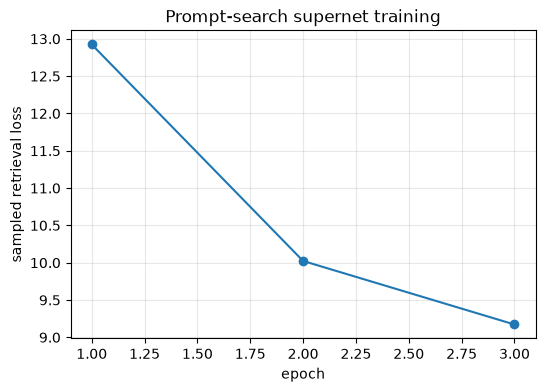

In [18]:
plt.figure(figsize=(6, 4))
plt.plot(history["epoch"], history["loss"], marker="o")
plt.xlabel("epoch")
plt.ylabel("sampled retrieval loss")
plt.title("Prompt-search supernet training")
plt.grid(True, alpha=0.3)
plt.show()

## Search and Evaluate Candidate Structures

The table below is the practical output of the NOAH-style search: it tells you which prompt length, negative weighting, fusion alpha, adapter widths, LoRA rank, and module placements worked best on validation retrieval.

In [21]:
search_table, best_candidate = search_candidates(
    supernet,
    validation_cases=validation_cases,
    num_candidates=2,
    ks=(1, 5, 10),
    score_metric="Recall@10",
    seed=SEED,
)

display(search_table)
print("Best candidate:", best_candidate)

Searching candidates:   0%|          | 0/2 [00:00<?, ?it/s]

candidate_0:   0%|          | 0/200 [00:00<?, ?it/s]

candidate_1:   0%|          | 0/200 [00:00<?, ?it/s]

,candidate_id,score_metric,score,active_ctx,negative_weight,image_alpha,adapter_dim,lora_rank,reference_module,text_module,fused_module
0,1,Recall@10,0.27,12,0.5,0.35,0,4,adapter,none,adapter
1,0,Recall@10,0.15,2,0.5,0.65,8,4,adapter,none,none


Best candidate: {'active_ctx': 12, 'negative_weight': 0.5, 'image_alpha': 0.35, 'adapter_dim': 0, 'lora_rank': 4, 'reference_module': 'adapter', 'text_module': 'none', 'fused_module': 'adapter'}


In [25]:
best_results_df = run_candidate(
    supernet,
    validation_cases,
    best_candidate,
    ks=(1, 5, 10),
    method_name="best_prompt_slerp_search",
)

summarize_results(best_results_df)

best_prompt_slerp_search:   0%|          | 0/1899 [00:00<?, ?it/s]

,query_id,query,Recall@1,Precision@1,Recall@5,Precision@5,Recall@10,Precision@10
0,0,+Smiling,0.048096,0.048096,0.166333,0.042485,0.256513,0.038076
1,1,+Eyeglasses,0.179537,0.179537,0.432432,0.131660,0.586873,0.114672
2,2,-Heavy_Makeup,0.017578,0.017578,0.095703,0.021875,0.156250,0.020117
3,3,+Male,0.056757,0.056757,0.237838,0.064324,0.321622,0.058919
4,ALL,All selected cases,0.077409,0.077409,0.233807,0.065508,0.332280,0.058189


In [26]:
best_results_df

,method,query_id,query,reference_id,n_gt,active_ctx,negative_weight,image_alpha,adapter_dim,lora_rank,reference_module,text_module,fused_module,Recall@1,Precision@1,Recall@5,Precision@5,Recall@10,Precision@10
0,best_prompt_slerp_search,2,-Heavy_Makeup,486,38,2,0.5,0.65,8,4,adapter,none,none,0,0.0,0,0.0,0,0.0
1,best_prompt_slerp_search,3,+Male,1080,19,2,0.5,0.65,8,4,adapter,none,none,0,0.0,0,0.0,1,0.1
2,best_prompt_slerp_search,2,-Heavy_Makeup,1700,49,2,0.5,0.65,8,4,adapter,none,none,0,0.0,0,0.0,0,0.0
3,best_prompt_slerp_search,1,+Eyeglasses,10438,11,2,0.5,0.65,8,4,adapter,none,none,0,0.0,0,0.0,0,0.0
4,best_prompt_slerp_search,0,+Smiling,4301,24,2,0.5,0.65,8,4,adapter,none,none,0,0.0,0,0.0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1894,best_prompt_slerp_search,1,+Eyeglasses,2365,13,2,0.5,0.65,8,4,adapter,none,none,0,0.0,1,0.2,1,0.1
1895,best_prompt_slerp_search,3,+Male,970,292,2,0.5,0.65,8,4,adapter,none,none,0,0.0,1,0.4,1,0.3
1896,best_prompt_slerp_search,0,+Smiling,873,30,2,0.5,0.65,8,4,adapter,none,none,0,0.0,1,0.2,1,0.1
1897,best_prompt_slerp_search,0,+Smiling,3727,7,2,0.5,0.65,8,4,adapter,none,none,0,0.0,0,0.0,0,0.0


## Full-Run Template

Uncomment this after the limited run behaves sensibly. It trains on more references, searches on a held-out split, then evaluates the best searched structure on all cases.

In [22]:
FULL_TRAIN_MAX_REFERENCES_PER_QUERY = None
FULL_EPOCHS = 20
FULL_SEARCH_CANDIDATES = 150
FULL_SEARCH_VAL_CAP = 500

full_train_pool = make_cases(
    annotations,
    image_embeddings,
    query_indices=None,
    max_references_per_query=FULL_TRAIN_MAX_REFERENCES_PER_QUERY,
)

full_train_cases, full_val_cases = split_cases(
    full_train_pool,
    validation_fraction=0.2,
    seed=SEED,
)

full_val_cases_for_search = full_val_cases[:FULL_SEARCH_VAL_CAP]

print(f"Full train pool: {len(full_train_pool)} cases")
print(f"Training cases: {len(full_train_cases)}")
print(f"Validation cases: {len(full_val_cases)}")
print(f"Validation cases used for search: {len(full_val_cases_for_search)}")

full_supernet = PromptSlerpSearchSupernet(
    attribute_names=raw_attributes,
    max_ctx=12,
    max_adapter_dim=128,
    max_lora_rank=32,
).to(device)

full_history = train_prompt_search_supernet(
    full_supernet,
    train_cases=full_train_cases,
    image_embeddings=image_embeddings,
    epochs=FULL_EPOCHS,
    batch_size=32,
    lr=2e-3,
    candidate_pool_size=2048,
    positives_per_case=1,
    fixed_candidate=None,
    seed=SEED,
)

full_search_table, full_best_candidate = search_candidates(
    full_supernet,
    validation_cases=full_val_cases_for_search,
    num_candidates=FULL_SEARCH_CANDIDATES,
    ks=(1, 5, 10),
    score_metric="Recall@10",
    seed=SEED,
)

display(full_search_table)
print("Best candidate:", full_best_candidate)

full_eval_cases = make_cases(
    annotations,
    image_embeddings,
    query_indices=None,
    max_references_per_query=None,
)

print(f"Full evaluation cases: {len(full_eval_cases)}")

full_results_df = run_candidate(
    full_supernet,
    full_eval_cases,
    full_best_candidate,
    ks=(1, 5, 10),
    method_name="full_best_prompt_slerp_search",
)

summarize_results(full_results_df)

Full train pool: 33052 cases
Training cases: 26442
Validation cases: 6610
Validation cases used for search: 500


Prompt-search epoch 1/20:   0%|          | 0/827 [00:00<?, ?it/s]

Prompt-search epoch 2/20:   0%|          | 0/827 [00:00<?, ?it/s]

Prompt-search epoch 3/20:   0%|          | 0/827 [00:00<?, ?it/s]

Prompt-search epoch 4/20:   0%|          | 0/827 [00:00<?, ?it/s]

...

candidate_149:   0%|          | 0/500 [00:00<?, ?it/s]

,candidate_id,score_metric,score,active_ctx,negative_weight,image_alpha,adapter_dim,lora_rank,reference_module,text_module,fused_module
0,8,Recall@10,0.508,2,0.80,0.50,64,4,adapter,both,both
1,120,Recall@10,0.508,12,0.50,0.50,64,16,adapter,adapter,adapter
2,102,Recall@10,0.508,12,0.65,0.50,64,16,both,none,both
3,73,Recall@10,0.502,4,0.50,0.35,64,4,adapter,adapter,both
4,140,Recall@10,0.500,8,0.50,0.50,64,4,none,adapter,adapter
...,...,...,...,...,...,...,...,...,...,...,...
145,41,Recall@10,0.120,8,0.50,0.80,64,16,none,none,none
146,24,Recall@10,0.118,4,0.65,0.80,8,0,none,both,lora
147,130,Recall@10,0.116,4,0.65,0.80,16,8,none,both,none
148,131,Recall@10,0.114,4,0.50,0.80,64,8,none,both,none


Best candidate: {'active_ctx': 2, 'negative_weight': 0.8, 'image_alpha': 0.5, 'adapter_dim': 64, 'lora_rank': 4, 'reference_module': 'adapter', 'text_module': 'both', 'fused_module': 'both'}
Full evaluation cases: 33052


full_best_prompt_slerp_search:   0%|          | 0/33052 [00:00<?, ?it/s]

,query_id,query,Recall@1,Precision@1,Recall@5,Precision@5,Recall@10,Precision@10
0,0,+Smiling,0.096114,0.096114,0.331383,0.087840,0.445675,0.071270
1,1,+Eyeglasses,0.455373,0.455373,0.689435,0.336248,0.770036,0.278005
2,2,-Heavy_Makeup,0.076095,0.076095,0.240029,0.065965,0.373868,0.059726
3,3,+Male,0.164890,0.164890,0.402508,0.144702,0.539185,0.136301
4,4,-Young,0.217740,0.217740,0.468721,0.164519,0.591597,0.136639
5,5,+Blond_Hair,0.161273,0.161273,0.363321,0.127848,0.483818,0.111373
6,6,+Mustache,0.262458,0.262458,0.564784,0.197342,0.694352,0.152159
7,7,-Young,0.217740,0.217740,0.468721,0.164519,0.591597,0.136639
8,8,"+Eyeglasses, +Smiling",0.700980,0.700980,0.905229,0.494118,0.946078,0.401961
9,9,"+Black_Hair, -Wavy_Hair",0.119362,0.119362,0.385303,0.112286,0.540824,0.102566


In [23]:
from pathlib import Path
import json
import torch

RESULTS_DIR = Path("finetuning_slerp_results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

full_results_df.to_csv(RESULTS_DIR / "full_results_df.csv", index=False)
summarize_results(full_results_df).to_csv(RESULTS_DIR / "full_summary_df.csv", index=False)
full_search_table.to_csv(RESULTS_DIR / "full_search_table.csv", index=False)
full_history.to_csv(RESULTS_DIR / "full_training_history.csv", index=False)

with open(RESULTS_DIR / "full_best_candidate.json", "w") as f:
    json.dump(full_best_candidate, f, indent=2)

torch.save(
    {
        "model_state_dict": full_supernet.state_dict(),
        "best_candidate": full_best_candidate,
        "raw_attributes": raw_attributes,
        "history": full_history.to_dict(orient="records"),
    },
    RESULTS_DIR / "full_supernet_checkpoint.pt",
)

print(f"Saved results to: {RESULTS_DIR.resolve()}")

Saved results to: /home/disi/deep_learning/DeepLearning2026/finetuning/finetuning_slerp_results


## What to Report

When you describe this experiment, the clean story is:

- CLIP is frozen.
- The model learns continuous positive and negative CoOp prompt tokens for each attribute.
- Attribute composition uses SLERP, so text-query construction respects cosine geometry.
- Text/image fusion also uses SLERP, so the final target remains on the CLIP unit sphere.
- A NOAH-style search explores prompt length, negative mass, fusion alpha, adapters, and LoRA-style residuals.
- The selected architecture is the one with the best validation retrieval metric.

This gives you an honest distinction from the earlier template-weight CoOp: here the prompt itself is trainable in embedding space.